# Validation 2: Score–affinity correlation

Spearman rank correlation between Rosetta summary scores (`rosetta_best_score`, `rosetta_mean_score`) and experimental log-affinity (IC50, Kd). Reports per-allele and pooled correlations.

Censored values at the assay detection limits are excluded.

Outputs: `correlations_per_allele.csv`, `correlations_pooled.json`, `figure3_score_vs_affinity.{png,pdf}` in `IEDB_validation/02_score_affinity/`.

Reads only `metadata.csv`; does not touch structure files.

## Setup

In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

sys.path.insert(0, str(Path.cwd()))
from utils import load_metadata, set_plot_style

set_plot_style()

In [2]:
# === Paths ===
HF_DIR     = Path('/home/huntek1/main_project/data/IEDB_data_clean/huggingface')
SCORES_DIR = Path('/home/huntek1/main_project/data/IEDB_data_clean/IEDB_validation/scores_out')
OUT_DIR    = Path('/home/huntek1/main_project/data/IEDB_data_clean/IEDB_validation/02_score_affinity')
OUT_DIR.mkdir(parents=True, exist_ok=True)

FIG3_DIR = Path('/home/huntek1/main_project/data/IEDB_data_clean/IEDB_validation/figure3_panels')
FIG3_DIR.mkdir(parents=True, exist_ok=True)

# === Column names ===
COL_ALLELE  = 'allele'
COL_PEPTIDE = 'peptide'
COL_FLAGGED = 'flagged'

# === Score metrics ===
# I_sc (interface score) is primary: it isolates the peptide-MHC interaction
# energy, whereas total_score is dominated by the invariant internal energy
# of the MHC receptor. reweighted_sc is reported alongside because it was
# used in prior applications of this pipeline (Bloodworth 2022, Patrick 2024).
PRIMARY_METRIC = 'I_sc'
METRICS        = ['I_sc', 'reweighted_sc', 'total_score', 'pep_sc']
SCORE_COLS     = {m: (f'{m}_best', f'{m}_mean') for m in METRICS}

# === Censoring ===
# Values equal to a recurrent assay ceiling, or at/above the highest ceiling,
# are non-quantitative and excluded. Thresholds chosen from the empirical
# value_counts spikes; see censoring_sensitivity.csv for the sensitivity analysis.
IC50_CEILINGS = (20000.0, 50000.0, 70000.0)
KD_CEILINGS   = (5000.0, 10000.0, 20000.0)
IC50_FLOOR    = 70000.0   # drop everything >= this
KD_FLOOR      = 20000.0

## Load and filter

In [3]:
df = load_metadata(HF_DIR / 'metadata.csv')
df = df[~df[COL_FLAGGED].astype(bool)].copy()

scores = pd.read_csv(SCORES_DIR / 'score_summary.csv')

def allele_to_dir(a):
    s = a[4:] if a.startswith('HLA-') else a
    return s.replace('*', '').replace(':', '')

df['allele_dir'] = df[COL_ALLELE].map(allele_to_dir)
before = len(df)
df = df.merge(scores, on=['allele_dir', 'peptide'], how='left', validate='many_to_one')

for m in METRICS:
    n_missing = df[f'{m}_best'].isna().sum()
    print(f'{m}: {n_missing:,} rows without a score ({n_missing/len(df)*100:.2f}%)')
assert len(df) == before, 'merge changed row count'

I_sc: 0 rows without a score (0.00%)
reweighted_sc: 0 rows without a score (0.00%)
total_score: 0 rows without a score (0.00%)
pep_sc: 0 rows without a score (0.00%)


In [5]:
# === Column schema ===
COL_MEAS_TYPE  = 'measurement_type'
COL_MEAS_VALUE = 'measurement_value'
COL_MEAS_UNITS = 'measurement_units'

# Quick sanity check on units (we assume nM throughout)
unit_counts = df[COL_MEAS_UNITS].value_counts()
print('Measurement units:')
print(unit_counts)
if not (unit_counts.index == 'nM').all():
    print('WARNING: non-nM units present; review before proceeding.')

def is_censored(values: pd.Series, ceilings: tuple, floor: float) -> pd.Series:
    """Censored if equal to a recurrent ceiling value or at/above the cutoff."""
    return values.isin(ceilings) | (values >= floor)

# Split into IC50 and Kd subsets
score_cols = [c for m in METRICS for c in SCORE_COLS[m]]

def prep(sub, ceilings, floor, label):
    sub = sub[[COL_ALLELE, COL_MEAS_VALUE] + score_cols].copy()
    sub = sub.dropna(subset=[COL_MEAS_VALUE, f'{PRIMARY_METRIC}_best'])
    sub = sub[~is_censored(sub[COL_MEAS_VALUE], ceilings, floor)]
    sub['log_value'] = np.log10(sub[COL_MEAS_VALUE])
    sub['affinity_type'] = label
    return sub

ic50 = prep(df[df[COL_MEAS_TYPE] == 'IC50'], IC50_CEILINGS, IC50_FLOOR, 'IC50')
kd   = prep(df[df[COL_MEAS_TYPE] == 'Kd'],   KD_CEILINGS,   KD_FLOOR,   'Kd')

print(f'\nUsable IC50 pairs: {len(ic50):,}')
print(f'Usable Kd pairs:   {len(kd):,}')

print('\nIC50 value distribution (post-filter):')
print(ic50[COL_MEAS_VALUE].describe())
print('\nKd value distribution (post-filter):')
print(kd[COL_MEAS_VALUE].describe())

Measurement units:
measurement_units
nM    49473
Name: count, dtype: int64

Usable IC50 pairs: 10,901
Usable Kd pairs:   9,517

IC50 value distribution (post-filter):
count    10901.000000
mean      9332.550522
std      15906.416692
min          0.001700
25%         98.000000
50%       1250.000000
75%      10808.000000
max      69924.810000
Name: measurement_value, dtype: float64

Kd value distribution (post-filter):
count     9517.000000
mean      1318.126556
std       2877.702626
min          0.100000
25%         23.000000
50%        161.000000
75%       1079.200000
max      19990.000000
Name: measurement_value, dtype: float64


## Pooled correlations

In [6]:
def spearman(x: np.ndarray, y: np.ndarray) -> dict:
    r = stats.spearmanr(x, y)
    return {'rho': float(r.statistic), 'pvalue': float(r.pvalue), 'n': int(len(x))}

pooled = {}
for assay, d in (('IC50', ic50), ('Kd', kd)):
    pooled[assay] = {}
    for m in METRICS:
        for agg, col in zip(('best', 'mean'), SCORE_COLS[m]):
            pooled[assay][f'{m}_{agg}'] = spearman(d[col], d['log_value'])

with open(OUT_DIR / 'correlations_pooled.json', 'w') as f:
    json.dump(pooled, f, indent=2)

print(pd.DataFrame({
    (a, m): {'rho': round(v['rho'], 3), 'p': f"{v['pvalue']:.2g}", 'n': v['n']}
    for a, mm in pooled.items() for m, v in mm.items()
}).T.to_string())

                           rho         p      n
IC50 I_sc_best           0.274  5.6e-187  10901
     I_sc_mean           0.219    2e-118  10901
     reweighted_sc_best  0.132   2.2e-43  10901
     reweighted_sc_mean  0.054   1.8e-08  10901
     total_score_best    0.029    0.0026  10901
     total_score_mean     0.01      0.28  10901
     pep_sc_best          0.11   5.8e-31  10901
     pep_sc_mean         0.031    0.0011  10901
Kd   I_sc_best           0.167     1e-60   9517
     I_sc_mean            0.14   6.2e-43   9517
     reweighted_sc_best  0.123   2.5e-33   9517
     reweighted_sc_mean  0.076   1.2e-13   9517
     total_score_best    0.063   9.8e-10   9517
     total_score_mean    0.043   3.1e-05   9517
     pep_sc_best         0.114   5.6e-29   9517
     pep_sc_mean         0.074   4.3e-13   9517


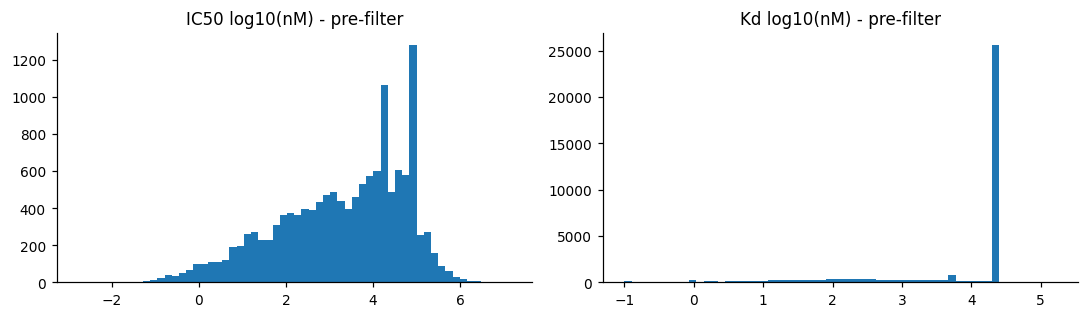

In [7]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].hist(np.log10(df[df[COL_MEAS_TYPE]=='IC50'][COL_MEAS_VALUE].dropna()), bins=60)
axes[0].set_title('IC50 log10(nM) - pre-filter')
axes[1].hist(np.log10(df[df[COL_MEAS_TYPE]=='Kd'][COL_MEAS_VALUE].dropna()), bins=60)
axes[1].set_title('Kd log10(nM) - pre-filter')
plt.tight_layout()
plt.show()

## Per-allele correlations

In [18]:
def per_allele_corr(d: pd.DataFrame, score_col: str, label: str) -> pd.DataFrame:
    rows = []
    for allele, g in d.groupby(COL_ALLELE):
        if len(g) < 10:
            continue
        s = spearman(g[score_col], g['log_value'])
        rows.append({'allele': allele, 'metric': label, **s})
    return pd.DataFrame(rows)

per_allele = pd.concat([
    per_allele_corr(d, col, f'{m}_{agg}_vs_log_{assay.lower()}')
    for assay, d in (('IC50', ic50), ('Kd', kd))
    for m in METRICS
    for agg, col in zip(('best', 'mean'), SCORE_COLS[m])
], ignore_index=True)
per_allele.to_csv(OUT_DIR / 'correlations_per_allele.csv', index=False)

per_allele.head(10)

,allele,metric,rho,pvalue,n
0,A*01:01,I_sc_best_vs_log_ic50,0.326464,4.288730e-06,190
1,A*02:01,I_sc_best_vs_log_ic50,0.353239,1.961178e-154,5261
2,A*03:01,I_sc_best_vs_log_ic50,0.108921,2.507733e-02,423
3,A*11:01,I_sc_best_vs_log_ic50,0.194401,2.242232e-05,469
4,A*23:01,I_sc_best_vs_log_ic50,0.588467,7.857538e-04,29
5,A*24:02,I_sc_best_vs_log_ic50,0.313351,7.707907e-15,587
6,A*26:01,I_sc_best_vs_log_ic50,0.703431,1.629430e-03,17
7,A*29:02,I_sc_best_vs_log_ic50,0.425640,2.560730e-03,48
8,A*30:01,I_sc_best_vs_log_ic50,0.018182,9.602404e-01,10
9,A*30:02,I_sc_best_vs_log_ic50,0.492590,4.874995e-03,31


## Figure 3: Score vs log-affinity (pooled, hex density)

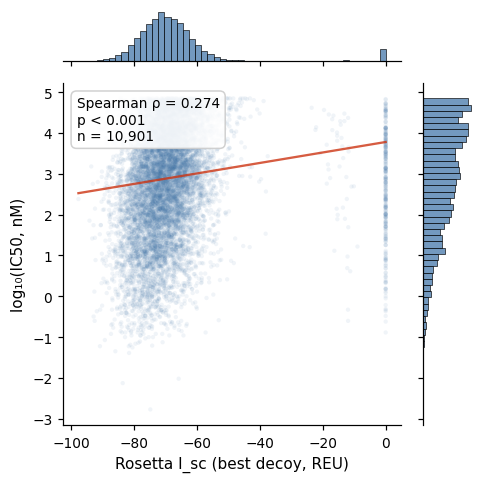

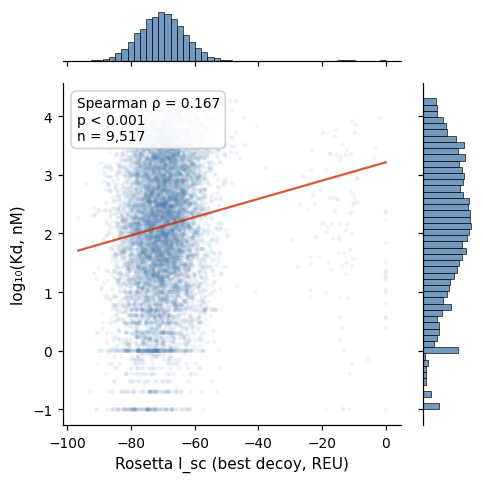

In [9]:
import seaborn as sns
from scipy.stats import linregress

SCORE_COL = f'{PRIMARY_METRIC}_best'
SCORE_LABEL = f'Rosetta {PRIMARY_METRIC} (best decoy, REU)'

lr_ic50 = linregress(ic50[SCORE_COL], ic50['log_value'])
lr_kd   = linregress(kd[SCORE_COL],   kd['log_value'])

def make_joint(data, ylabel, title, slope_intercept, rho_dict, out_name):
    g = sns.jointplot(
        data=data, x=SCORE_COL, y='log_value',
        kind='scatter',
        height=4.5,
        marginal_kws=dict(bins=50, fill=True, color='#4477AA'),
        joint_kws=dict(alpha=0.08, s=8, color='#4477AA', edgecolor='none'),
    )
    x = np.linspace(data[SCORE_COL].min(), data[SCORE_COL].max(), 100)
    g.ax_joint.plot(x, slope_intercept.slope * x + slope_intercept.intercept,
                    color='#CC3311', linewidth=1.5, alpha=0.8)
    g.ax_joint.set_xlabel(SCORE_LABEL)
    g.ax_joint.set_ylabel(ylabel)

    p_str = ('p < 0.001' if rho_dict['pvalue'] < 0.001
             else f"p = {rho_dict['pvalue']:.3f}")
    rho_disp = 0.0 if abs(rho_dict['rho']) < 5e-3 else rho_dict['rho']

    g.ax_joint.text(
        0.04, 0.96,
        f"Spearman ρ = {rho_disp:.3f}\n{p_str}\nn = {rho_dict['n']:,}",
        transform=g.ax_joint.transAxes,
        ha='left', va='top', fontsize=9,
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                  edgecolor='#cccccc', alpha=0.9))

    g.figure.tight_layout()
    g.figure.savefig(FIG3_DIR / f'{out_name}.png', dpi=300, bbox_inches='tight')
    g.figure.savefig(FIG3_DIR / f'{out_name}.pdf', bbox_inches='tight')
    return g

make_joint(ic50, 'log₁₀(IC50, nM)', 'IC50', lr_ic50,
           pooled['IC50'][f'{PRIMARY_METRIC}_best'],
           f'figure3a_ic50_vs_{PRIMARY_METRIC}')
make_joint(kd,   'log₁₀(Kd, nM)',   'Kd',   lr_kd,
           pooled['Kd'][f'{PRIMARY_METRIC}_best'],
           f'figure3b_kd_vs_{PRIMARY_METRIC}')
plt.show()

In [10]:
print('Pipeline counts:')
print(f'  Total metadata rows (post-flag-drop): {len(df):,}')

SCORE_COL = f'{PRIMARY_METRIC}_best'

for measurement_type, ceilings, floor in [
        ('IC50', IC50_CEILINGS, IC50_FLOOR),
        ('Kd',   KD_CEILINGS,   KD_FLOOR)]:
    sub = df[df[COL_MEAS_TYPE] == measurement_type].copy()
    n_total = len(sub)

    sub_nonnan = sub.dropna(subset=[COL_MEAS_VALUE, SCORE_COL])
    n_after_nan = len(sub_nonnan)

    censored = is_censored(sub_nonnan[COL_MEAS_VALUE], ceilings, floor)
    n_censored = int(censored.sum())
    n_after_censor = n_after_nan - n_censored

    print(f'\n  {measurement_type}:')
    print(f'    Rows of this measurement type:        {n_total:,}')
    print(f'    After dropping NaN score/value:       {n_after_nan:,}   (lost {n_total - n_after_nan:,})')
    print(f'    Of those, censored:                   {n_censored:,}   ({n_censored/n_after_nan*100:.1f}%)')
    print(f'    Usable (kept for correlation):        {n_after_censor:,}   ({n_after_censor/n_total*100:.1f}% of type total)')

Pipeline counts:
  Total metadata rows (post-flag-drop): 49,473

  IC50:
    Rows of this measurement type:        13,622
    After dropping NaN score/value:       13,622   (lost 0)
    Of those, censored:                   2,721   (20.0%)
    Usable (kept for correlation):        10,901   (80.0% of type total)

  Kd:
    Rows of this measurement type:        35,851
    After dropping NaN score/value:       35,851   (lost 0)
    Of those, censored:                   26,334   (73.5%)
    Usable (kept for correlation):        9,517   (26.5% of type total)


In [11]:
# What "round number" values appear suspiciously often? These are likely censoring values.
for measurement_type in ['IC50', 'Kd']:
    sub = df[df[COL_MEAS_TYPE] == measurement_type][COL_MEAS_VALUE]
    counts = sub.value_counts().head(10)
    print(f'\n{measurement_type}: top 10 most common values:')
    print(counts)


IC50: top 10 most common values:
measurement_value
70000.0     730
20000.0     565
100000.0    169
50000.0      70
12.0         52
11.0         49
13.0         47
14.0         44
17.0         40
16.0         37
Name: count, dtype: int64

Kd: top 10 most common values:
measurement_value
20000.0    25571
5000.0       611
1.0          212
0.1          115
2.0           63
5.0           59
0.2           57
3.0           54
10000.0       52
4.0           43
Name: count, dtype: int64


## Per-allele correlation distribution

In [12]:
def summarize_per_allele(d: pd.DataFrame) -> dict:
    return {
        'n_alleles':           len(d),
        'median_rho':          d['rho'].median(),
        'iqr_rho':             (d['rho'].quantile(0.25), d['rho'].quantile(0.75)),
        'n_significant':       int((d['pvalue'] < 0.05).sum()),
        'pct_significant':     (d['pvalue'] < 0.05).mean() * 100,
        'n_rho_above_0.3':     int((d['rho'] > 0.3).sum()),
        'n_negative':          int((d['rho'] < 0).sum()),
    }

summary_rows = []
for label, group in per_allele.groupby('metric'):
    s = summarize_per_allele(group)
    summary_rows.append({'metric': label, **s})

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(OUT_DIR / 'per_allele_summary.csv', index=False)
print(summary_df.to_string(index=False))

                        metric  n_alleles  median_rho                                      iqr_rho  n_significant  pct_significant  n_rho_above_0.3  n_negative
         I_sc_best_vs_log_ic50         28    0.182534    (0.0988287111301559, 0.36628698247784114)             17        60.714286               11           2
           I_sc_best_vs_log_kd         25    0.156621    (0.08256125440826317, 0.2208745635939014)             16        64.000000                2           3
         I_sc_mean_vs_log_ic50         28    0.203548   (0.08507100159819983, 0.32489126583700134)             15        53.571429                8           2
           I_sc_mean_vs_log_kd         25    0.118862   (0.07334972553842894, 0.23998602412982056)             12        48.000000                2           3
       pep_sc_best_vs_log_ic50         28    0.088490   (-0.05140710046010965, 0.1883567083988789)              9        32.142857                5          10
         pep_sc_best_vs_log_kd         2

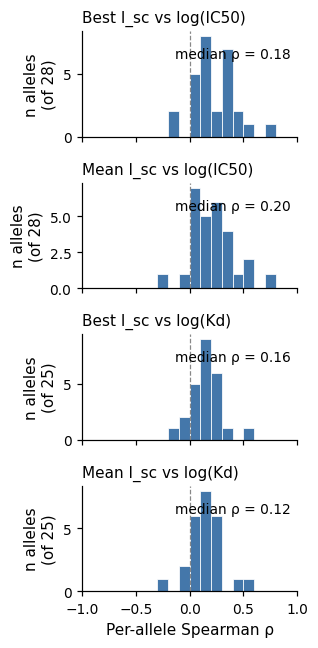

In [15]:
fig, axes = plt.subplots(4, 1, figsize=(3, 6), sharex=True)
metrics = [f'{PRIMARY_METRIC}_best_vs_log_ic50',
           f'{PRIMARY_METRIC}_mean_vs_log_ic50',
           f'{PRIMARY_METRIC}_best_vs_log_kd',
           f'{PRIMARY_METRIC}_mean_vs_log_kd']
titles  = [f'Best {PRIMARY_METRIC} vs log(IC50)',
           f'Mean {PRIMARY_METRIC} vs log(IC50)',
           f'Best {PRIMARY_METRIC} vs log(Kd)',
           f'Mean {PRIMARY_METRIC} vs log(Kd)']

for ax, metric, title in zip(axes, metrics, titles):
    sub = per_allele[per_allele['metric'] == metric]
    ax.hist(sub['rho'], bins=np.arange(-1, 1.05, 0.1), color='#4477AA',
            edgecolor='white', linewidth=0.5)
    ax.axvline(0, color='#888888', linewidth=0.8, linestyle='--')
    ax.set_ylabel(f'n alleles\n(of {len(sub)})')
    ax.text(0.97, 0.85,
            f'median ρ = {sub["rho"].median():.2f}',
            transform=ax.transAxes, ha='right', va='top', fontsize=9)
    ax.set_title(title, fontsize=10, loc='left')

axes[-1].set_xlabel('Per-allele Spearman ρ')
axes[-1].set_xlim(-1, 1)
fig.tight_layout()
fig.savefig(FIG3_DIR / 'figure3b_per_allele_correlations.png', dpi=300)
fig.savefig(FIG3_DIR / 'figure3b_per_allele_correlations.pdf')
plt.show()

In [16]:
strong_alleles = per_allele[
    (per_allele['metric'] == f'{PRIMARY_METRIC}_best_vs_log_ic50')
    & (per_allele['rho'] > 0.3)
].sort_values('rho', ascending=False)
print(strong_alleles)

     allele                 metric       rho         pvalue     n
6   A*26:01  I_sc_best_vs_log_ic50  0.703431   1.629430e-03    17
4   A*23:01  I_sc_best_vs_log_ic50  0.588467   7.857538e-04    29
9   A*30:02  I_sc_best_vs_log_ic50  0.492590   4.874995e-03    31
7   A*29:02  I_sc_best_vs_log_ic50  0.425640   2.560730e-03    48
26  B*53:01  I_sc_best_vs_log_ic50  0.398436   2.227911e-06   132
18  B*35:01  I_sc_best_vs_log_ic50  0.384390   1.195929e-06   150
17  B*27:05  I_sc_best_vs_log_ic50  0.375979   6.547727e-03    51
16  B*18:01  I_sc_best_vs_log_ic50  0.363056   2.130428e-02    40
1   A*02:01  I_sc_best_vs_log_ic50  0.353239  1.961178e-154  5261
0   A*01:01  I_sc_best_vs_log_ic50  0.326464   4.288730e-06   190
5   A*24:02  I_sc_best_vs_log_ic50  0.313351   7.707907e-15   587


In [17]:
neg_alleles = per_allele[
    (per_allele['metric'] == f'{PRIMARY_METRIC}_best_vs_log_kd')
    & (per_allele['rho'] < 0)
].sort_values('rho')
print(neg_alleles)

      allele               metric       rho    pvalue    n
230  A*25:01  I_sc_best_vs_log_kd -0.148969  0.225346   68
235  A*68:02  I_sc_best_vs_log_kd -0.024380  0.767126  150
238  B*14:02  I_sc_best_vs_log_kd -0.024316  0.946840   10
